![alternative text](../logo.png)

# EFAS Seasonal – River Discharge outlook example

This notebook shows how to retrieve **EFAS seasonal forecast data** using the `efas-seasonal` dataset,
using river discharge as an example.

In this example, you will:

1. Build and send a data request using a **bounding box** or a **polygon**
2. Decode the CoverageJSON data into an **xarray Dataset**
3. Visualise the data using the EarthKit plots package (Optional)

---

### What is the EFAS seasonal outlook?

**EFAS** (**E**uropean **F**lood **A**wareness **S**ystem) is the flood forecasting component of the
Copernicus Emergency Management Service. Alongside its medium-range forecasts (see
`efas_forecast_example.ipynb`), EFAS produces a **seasonal outlook**: the LISFLOOD hydrological model,
run on a 5 km grid, is driven by ECMWF's **SEAS5** seasonal ensemble. That gives **51 ensemble members**
looking months rather than days ahead.

More information about **available variables** and **request fields** can be found in:
- README and constraints/efas-seasonal.json
- https://ewds.climate.copernicus.eu/datasets/efas-seasonal?tab=overview

> **Note:** EFAS data is served from the EWDS (Early Warning Data Service) endpoint
> rather than the standard CDS. This is handled automatically by the API.


## Imports and shared settings

In [1]:
# Uncomment and run this cell if you need to install the dependencies
#!pip install -r requirements.txt

In [1]:
#Data requests and decode
import numpy as np
import requests
import xarray as xr

#Data visualisation
import earthkit.plots as ekp

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="earthkit")

# API endpoint template
base_url = 'https://polytope-dss.ecmwf.int/api/v1/dataset/{dataset}/extract/'

headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json',
}

# Seasonal requests pull 51 ensemble members out of the archive and take a few minutes
# each. Extraction is synchronous and the gateway drops the connection at about five
# minutes, so whether a given attempt makes it is partly luck - ask again rather than fail.
TIMEOUT = 300

def post_with_retry(url, payload, attempts=5):
    """POST an extraction request, retrying the dropped connections."""
    for attempt in range(1, attempts + 1):
        try:
            response = requests.post(url, headers=headers, json=payload, timeout=TIMEOUT)
            if response.status_code == 200:
                return response
            print(f'  attempt {attempt}: HTTP {response.status_code}, retrying')
        except requests.exceptions.RequestException as exc:
            print(f'  attempt {attempt}: {type(exc).__name__}, retrying')
    raise RuntimeError('request did not succeed - try again in a few minutes')
# Multi-hue scales: a one-hue ramp spends its lower half on near-white tints that are
# hard to tell apart. Cool for the mean, warm for the spread, so the two never get confused.


---

## Example 1 – Bounding-box query

A **bounding box** selects all grid points inside a rectangular region defined by two corner coordinates.

In this example, we retrieve **river discharge in the last 24 hours** — the average volume of water
flowing past each grid point over a 24-hour window, in m³/s — from the outlook initialised on
**1 November 2020**, the first operational seasonal forecast.

The bounding box covers the **Meuse and Rhine confluence area** (roughly 49.5°N–51.5°N, 4.5°E–7°E). We
send the **same request twice**, at two lead times: **+24 hours** (+1 day) and **+720 hours** (+30 days).
With 51 members at each, that gives us four fields to compare — the ensemble **mean** and the ensemble
**spread** at a short and a long range — which is the most informative thing a seasonal ensemble can show.

> **Expect these cells to be slow, and to need retrying.** Each request assembles 51 members from the
> archive and takes a few minutes. Extraction is synchronous and the gateway drops the connection at about
> five minutes, so `post_with_retry` simply asks again — an individual attempt failing is normal, not a
> sign that the request is wrong.

The API returns data in **CoverageJSON** format.

### 1.1 Send the request

In [2]:
bbox_coordinates = [[49.5, 4.5], [51.5, 7.0]]   # [lat_min, lon_min], [lat_max, lon_max]

def bbox_request(leadtime_hour):
    return {
        'request': {
            'variable': ['river_discharge_in_the_last_24_hours'],
            'year': ['2020'],
            'month': ['11'],
            'leadtime_hour': [leadtime_hour],
        },
        'feature': {
            'type': 'boundingbox',
            # Coordinates are [lat_min, lon_min] and [lat_max, lon_max]
            'coordinates': bbox_coordinates,
        },
    }

url = base_url.format(dataset='efas-seasonal')

print('Requesting +1 day:')
response_24 = post_with_retry(url, bbox_request('24'))
print('Requesting +30 days:')
response_720 = post_with_retry(url, bbox_request('720'))

#Print the response status codes
print('Status +1 day:  ', response_24.status_code)
print('Status +30 days:', response_720.status_code)

Requesting +1 day:
Requesting +30 days:
Status +1 day:   200
Status +30 days: 200


### 1.2 Decode the response

The response is a [CoverageJSON](https://covjson.org) `CoverageCollection`. Because
EFAS uses a non-standard projected grid, the `covjsonkit` decoder may not handle the
output directly — the raw JSON can be inspected or processed with custom code.


In [3]:
def covjson_to_xarray(covjson, parameter):
    """Assemble a (member, points) Dataset from an efas-seasonal CoverageJSON.

    Each coverage is one ensemble member; they all share the same point coordinates.
    """
    coverages = covjson['coverages']

    # The 'composite' axis holds one [latitude, longitude, level] triple per point
    points = coverages[0]['domain']['axes']['composite']['values']
    latitude = np.array([p[0] for p in points], dtype=float)
    longitude = np.array([p[1] for p in points], dtype=float)

    values = np.array([c['ranges'][parameter]['values'] for c in coverages],
                      dtype=float)

    metadata = covjson['parameters'][parameter]
    data = xr.DataArray(values, dims=('member', 'points'))
    data.attrs = {
        'type': metadata.get('type', 'Parameter'),
        'units': metadata['unit']['symbol'],
        'long_name': metadata['observedProperty']['id'],
    }

    return xr.Dataset(
        {parameter: data},
        coords={
            'member': np.arange(values.shape[0]),
            'latitude': ('points', latitude),
            'longitude': ('points', longitude),
        },
    )


ds_24 = covjson_to_xarray(response_24.json(), 'dis24')
ds_720 = covjson_to_xarray(response_720.json(), 'dis24')
ds_24

<xarray.Dataset> Size: 669kB
Dimensions:    (member: 51, points: 1576)
Coordinates:
  * member     (member) int64 408B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
    latitude   (points) float64 13kB 51.49 51.49 51.5 ... 49.51 49.51 49.51
    longitude  (points) float64 13kB 4.545 4.616 4.688 ... 6.845 6.914 6.983
Dimensions without coordinates: points
Data variables:
    dis24      (member, points) float64 643kB 0.1201 0.6143 ... 4.369 0.3682

### 1.3 Visualise the data

In this example, we plot all four fields on one figure: the **ensemble mean** on the top row and the
**ensemble spread** (the standard deviation across the 51 members) on the bottom row, with +1 day on the
left and +30 days on the right.

We use **Earthkit Plots** package to visualise the data.
Please, find more information and documentation of the package here:
https://earthkit-plots.readthedocs.io


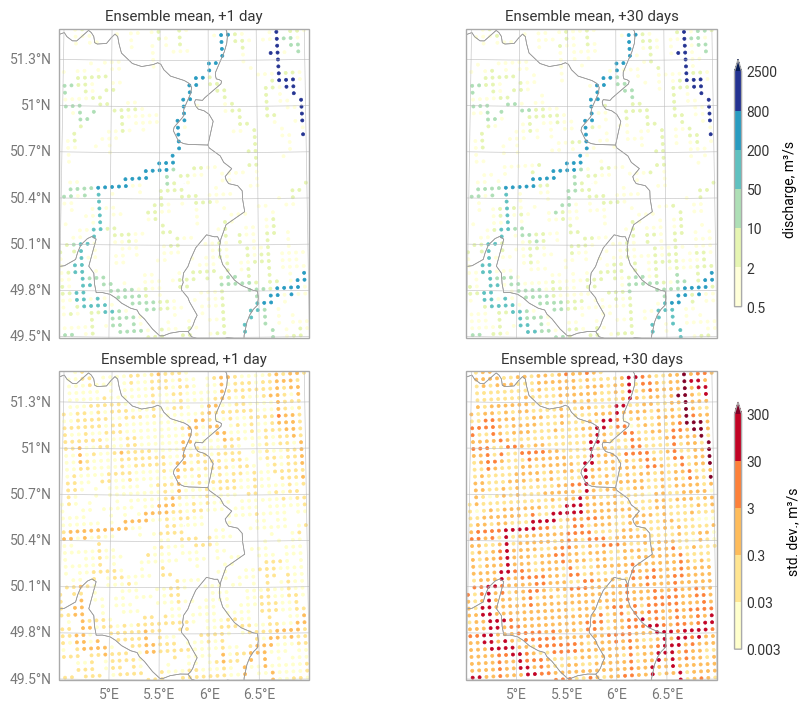

In [7]:
# Both lead times come back on the same grid, so one set of coordinates serves all four panels.
mean_levels = [0.5, 2, 10, 50, 200, 800, 2500]
spread_levels = [0.003, 0.03, 0.3, 3, 30, 300]
panels = [
    ('Ensemble mean, +1 day',     ds_24['dis24'].mean(dim='member'),  mean_levels,   'YlGnBu',   'discharge, m³/s'),
    ('Ensemble mean, +30 days',   ds_720['dis24'].mean(dim='member'), mean_levels,   'YlGnBu',   'discharge, m³/s'),
    ('Ensemble spread, +1 day',   ds_24['dis24'].std(dim='member'),   spread_levels, 'YlOrRd', 'std. dev., m³/s'),
    ('Ensemble spread, +30 days', ds_720['dis24'].std(dim='member'),  spread_levels, 'YlOrRd', 'std. dev., m³/s'),
]

figure = ekp.Figure(rows=2, columns=2, domain=[4.5, 7.0, 49.5, 51.5])

for index, (title, field, levels, colors, label) in enumerate(panels):
    ax = figure.add_map()
    ax.point_cloud(field,
        x=ds_24['longitude'],
        y=ds_24['latitude'],
        units='m3/s',
        s=5,
        style=ekp.Style(levels=levels, colors=colors, extend='max'))
    ax.title(title)
    if index in (1, 3):
        ax.legend(label=label, location='right')

figure.coastlines()
figure.borders()
figure.gridlines()
figure.show()

The Meuse and the Rhine show up as the darkest lines of points in the top row, with discharge increasing
downstream as more and more catchment area drains into the main channel. The two mean panels look much
alike: the median grid point rises from 0.4 to 0.6 m³/s while the peak on the Rhine falls by about a
quarter, so the outlook is not calling for anything dramatic at either range.

The bottom row is where the two lead times part company, and it is the reason to run an ensemble at all.
Take the main channels — the wettest 5 % of grid points, carrying around 250 m³/s in the mean. At
**+1 day** their spread is under 1 m³/s, a few tenths of a percent of the mean. At **+30 days**, the spread on those same
points is about 230 m³/s — as large as the mean itself.

---

## Example 2 – Polygon query

A **polygon** selects grid points inside an arbitrary shape. This is useful when
your area of interest follows administrative boundaries, a river catchment, or
any non-rectangular outline.

Rules for polygon coordinates:

- Each point is `[lat, lon]`
- The polygon must be **closed**: the first and last point must be identical
- At least 4 points are needed (3 unique corners + the closing repeat)

The polygon below roughly traces **Belgium**, which is drained by the Meuse and the Scheldt. Notice that
**only the `feature` block changes** – the `request` dict is the same as in the bounding box example.


### 2.1 Send the request

In [7]:
polygon_request = {
    'request': {
        'variable': ['river_discharge_in_the_last_24_hours'],
        'year': ['2020'],
        'month': ['11'],
        'day': ['01'],
        'leadtime_hour': ['24'],
    },
    'feature': {
        'type': 'polygon',
        # Closed polygon of [lat, lon] pairs – first point must equal last point
        'coordinates': [[51.09, 2.54], [51.35, 3.35], [51.47, 4.53], [51.50, 5.05],
                        [51.19, 5.85], [50.75, 6.02], [50.32, 6.41], [49.80, 6.13],
                        [49.53, 5.82], [49.65, 5.45], [49.95, 4.85], [50.14, 4.15],
                        [50.50, 3.65], [50.78, 3.15], [50.79, 2.57], [51.09, 2.54]],
    },
}

url_poly = base_url.format(dataset='efas-seasonal')
response_poly = post_with_retry(url_poly, polygon_request)

# Print the response status code
print('Status:', response_poly.status_code)

Status: 200


### 2.2 Decode the response

We reuse the same helper as in the previous example.


In [8]:
ds_poly = covjson_to_xarray(response_poly.json(), 'dis24')
ds_poly

<xarray.Dataset> Size: 566kB
Dimensions:    (member: 51, points: 1334)
Coordinates:
  * member     (member) int64 408B 0 1 2 3 4 5 6 7 8 ... 43 44 45 46 47 48 49 50
    latitude   (points) float64 11kB 51.43 51.43 51.43 ... 49.61 49.56 49.56
    longitude  (points) float64 11kB 4.12 4.191 4.263 ... 5.868 5.734 5.803
Dimensions without coordinates: points
Data variables:
    dis24      (member, points) float64 544kB 0.6064 0.3135 ... 0.2939 2.229

### 2.3 Visualise the data

Here we plot the ensemble mean next to the ensemble spread for the +1 day lead time.

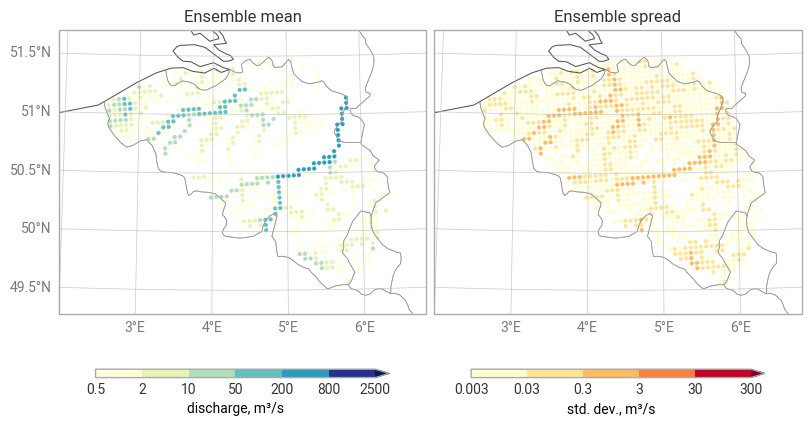

In [9]:
mean_levels = [0.5, 2, 10, 50, 200, 800, 2500]
spread_levels = [0.003, 0.03, 0.3, 3, 30, 300]

figure = ekp.Figure(rows=1, columns=2, domain=[2.0, 6.8, 49.3, 51.7])

ax = figure.add_map()
ax.point_cloud(ds_poly['dis24'].mean(dim='member'),
    x=ds_poly['longitude'],
    y=ds_poly['latitude'],
    units='m3/s',
    s=6,
    style=ekp.Style(levels=mean_levels, colors='YlGnBu', extend='max'))
ax.title('Ensemble mean')
ax.legend(label='discharge, m³/s')

ax = figure.add_map()
ax.point_cloud(ds_poly['dis24'].std(dim='member'),
    x=ds_poly['longitude'],
    y=ds_poly['latitude'],
    units='m3/s',
    s=6,
    style=ekp.Style(levels=spread_levels, colors='YlOrRd', extend='max'))
ax.title('Ensemble spread')
ax.legend(label='std. dev., m³/s')

figure.coastlines()
figure.borders()
figure.gridlines()
figure.show()

Only the grid points inside the polygon are returned, so the shape of Belgium is traced out by the data
itself. The Meuse and the Scheldt read clearly in the mean, and the spread is concentrated along the same
channels.

---

## Next steps

Now that you can retrieve the data, here are some things to try next:

- **Swap the variable** – replace river discharge with any of the available
  variables (e.g. soil wetness index, snow depth water equivalent, volumetric soil moisture)
- **Fill in the lead times between** – Example 1 jumps straight from +1 day to +30 days; request the steps
  in between and watch the spread grow smoothly
- **Look at the members individually** – instead of the mean, plot a few members side by side, or compute
  a percentile across the `member` dimension to ask "how bad could it plausibly get?"
- **Plot the spread as a fraction of the mean** – dividing the standard deviation by the mean gives a
  coefficient of variation, which is comparable between a small tributary and the Rhine
- **Compare initialisation months** – the same basin initialised in November and in March tells you very
  different things about the season ahead
- **Use a real boundary** – load a catchment or country shapefile and convert it to a
  polygon for the API

Please see the constraints file, which contains the valid values for the dataset — bearing in mind the
caveat noted at the top of this notebook.